# Penmanshiel SCADA: Multiclass Failure-Type Classification To ONNX Export


Workflow:
1. Load Penmanshiel static metadata, signal mapping, SCADA files, and status files.
2. Join status intervals onto 10-minute SCADA rows.
3. Visualize correlations and event behavior.
4. Build a leakage-aware multiclass modeling dataset.
5. Train and evaluate a multiclass classifier.
6. Export the trained pipeline to ONNX and smoke-test it with ONNX Runtime.

## 1. Paths And Dependencies

Update the paths below if your files move. The dependency cell installs missing packages into the active notebook kernel.

In [26]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = Path(r"C:\Users\KIPTOON\Downloads\Penmanshiel_SCADA_2016_WT01-10_3107")
STATIC_PATH = Path(r"C:\Users\KIPTOON\Downloads\Penmanshiel_WT_static.csv")
SIGNAL_MAPPING_PATH = Path(r"C:\Users\KIPTOON\Downloads\Penmanshiel_WT_dataSignalMapping.xlsx")

OUTPUT_DIR = PROJECT_ROOT / "notebook_outputs" / "penmanshiel"
MODEL_REPOSITORY = PROJECT_ROOT / "model_repository" / "notebook-penmanshiel-event-type-onnx"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_REPOSITORY.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Output dir:", OUTPUT_DIR)
print("Model repository:", MODEL_REPOSITORY)

Project root: C:\Users\KIPTOON\Documents\Playground\wind-onnx-mlops-takehome
Data dir: C:\Users\KIPTOON\Downloads\Penmanshiel_SCADA_2016_WT01-10_3107
Output dir: C:\Users\KIPTOON\Documents\Playground\wind-onnx-mlops-takehome\notebook_outputs\penmanshiel
Model repository: C:\Users\KIPTOON\Documents\Playground\wind-onnx-mlops-takehome\model_repository\notebook-penmanshiel-event-type-onnx


### 1.2 install relevant packages

In [54]:
!pip install -r ../requirements.txt

In [28]:
import json
import re
from datetime import datetime, timezone

import joblib
import matplotlib.pyplot as plt
import numpy as np
import onnxruntime as ort
import pandas as pd
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, balanced_accuracy_score, top_k_accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 140)
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True

## 2. Inspect The Input Files

In [29]:
scada_files = sorted(DATA_DIR.glob("Turbine_Data_*.csv"))
status_files = sorted(DATA_DIR.glob("Status_*.csv"))

print(f"SCADA files: {len(scada_files)}")
print(f"Status files: {len(status_files)}")
display(pd.DataFrame({"scada_file": [p.name for p in scada_files], "size_mb": [p.stat().st_size / 1_000_000 for p in scada_files]}))

static = pd.read_csv(STATIC_PATH).dropna(axis=1, how="all")
signal_mapping = pd.read_excel(SIGNAL_MAPPING_PATH)

display(static.head())
display(signal_mapping.head(15))

SCADA files: 9
Status files: 9


,scada_file,size_mb
0,Turbine_Data_Penmanshiel_01_2016-06-06_-_2017-01-01_1042.csv,82.365300
1,Turbine_Data_Penmanshiel_02_2016-06-03_-_2017-01-01_1043.csv,83.797237
2,Turbine_Data_Penmanshiel_04_2016-06-13_-_2017-01-01_1044.csv,80.597209
3,Turbine_Data_Penmanshiel_05_2016-06-15_-_2017-01-01_1045.csv,81.385338
4,Turbine_Data_Penmanshiel_06_2016-06-02_-_2017-01-01_1046.csv,79.863124
5,Turbine_Data_Penmanshiel_07_2016-06-02_-_2017-01-01_1047.csv,84.587060
6,Turbine_Data_Penmanshiel_08_2016-07-27_-_2017-01-01_1048.csv,58.591766
7,Turbine_Data_Penmanshiel_09_2016-06-24_-_2017-01-01_1049.csv,63.930217
8,Turbine_Data_Penmanshiel_10_2016-06-27_-_2017-01-01_1050.csv,62.629196


,Wind Farm,Title,Alternative Title,Identity,Manufacturer,Model,Rated power (kW),Hub Height (m),Rotor Diameter (m),Latitude,Longitude,Elevation (m),Country,Commercial Operations Date
0,Penmanshiel,Penmanshiel 01,T01,MM82/59 82765-01,Senvion,MM82,2050.0,59.0,82.0,55.902502,-2.306389,212.26,UK,01/09/2016
1,Penmanshiel,Penmanshiel 02,T02,MM82/59 82766-02,Senvion,MM82,2050.0,59.0,82.0,55.900008,-2.301268,200.46,UK,01/09/2016
2,Penmanshiel,Penmanshiel 04,T04,MM82/59 82768-04,Senvion,MM82,2050.0,59.0,82.0,55.905943,-2.302690,208.91,UK,01/09/2016
3,Penmanshiel,Penmanshiel 05,T05,MM82/59 82769-05,Senvion,MM82,2050.0,59.0,82.0,55.903294,-2.298367,201.38,UK,01/09/2016
4,Penmanshiel,Penmanshiel 06,T06,MM82/59 82770-06,Senvion,MM82,2050.0,59.0,82.0,55.900951,-2.293967,199.03,UK,01/09/2016


,DataSignalId,TitleGreenbyte,TitleManufacturer,Unit,MinValue,MaxValue
0,1,Wind speed,Wind speed,m/s,-10,80
1,2,Wind direction,Wind direction,°,0,360
2,3,Nacelle position,Nacelle orientation,°,0,360
3,4,Energy Export,Entire active energy generation,kWh,-1000,\t
4,5,Power,Actual value of active power,kW,-1000,10000
5,6,Power factor (cosphi),Power factor,NaN,-1,1
6,7,Reactive power,Actual value of reactive power,kvar,-1000,10000
7,9,Front bearing temperature,Axle bearing temperature 1,°C,-275,200
8,10,Rear bearing temperature,Axle bearing temperature 2,°C,-275,200
9,22,Stator temperature 1,Temperature for generator stator,°C,-275,200


The SCADA CSV files contain Greenbyte metadata at the top. The actual header starts on row 10, so we read them with `skiprows=9`.

In [30]:
sample_scada_header = pd.read_csv(scada_files[0], skiprows=9, nrows=0)
sample_status = pd.read_csv(status_files[0], skiprows=9, nrows=5)

print("SCADA column count:", len(sample_scada_header.columns))
print(sample_scada_header.columns[:30].tolist())
display(sample_status)

SCADA column count: 300
['# Date and time', 'Wind speed (m/s)', 'Wind speed, Standard deviation (m/s)', 'Wind speed, Minimum (m/s)', 'Wind speed, Maximum (m/s)', 'Long Term Wind (m/s)', 'Wind speed Sensor 1 (m/s)', 'Wind speed Sensor 1, Standard deviation (m/s)', 'Wind speed Sensor 1, Minimum (m/s)', 'Wind speed Sensor 1, Maximum (m/s)', 'Wind speed Sensor 2 (m/s)', 'Wind speed Sensor 2, Standard deviation (m/s)', 'Wind speed Sensor 2, Minimum (m/s)', 'Wind speed Sensor 2, Maximum (m/s)', 'Density adjusted wind speed (m/s)', 'Wind direction (°)', 'Nacelle position (°)', 'Wind direction, Standard deviation (°)', 'Wind direction, Minimum (°)', 'Wind direction, Maximum (°)', 'Nacelle position, Standard deviation (°)', 'Nacelle position, Minimum (°)', 'Nacelle position, Maximum (°)', 'Vane position 1+2 (°)', 'Vane position 1+2, Max (°)', 'Vane position 1+2, Min (°)', 'Vane position 1+2, StdDev (°)', 'Energy Export (kWh)', 'Energy Export counter (kWh)', 'Energy Import (kWh)']


,Timestamp start,Timestamp end,Duration,Status,Code,Message,Comment,Service contract category,IEC category
0,2016-06-06 17:08:40,2016-06-10 11:28:00,90:19:20,Stop,3500,Grid loss,NaN,External stop (grid) (4),Out of Electrical Specification
1,2016-06-06 17:08:41,2016-06-06 18:14:07,01:05:26,Warning,3875,Overload transf. fan inlet air,NaN,Warnings (27),NaN
2,2016-06-06 17:08:41,2016-06-06 18:14:39,01:05:58,Warning,1825,Overload gear bypass filter,NaN,Warnings (27),NaN
3,2016-06-06 17:08:41,2016-06-06 18:14:07,01:05:26,Warning,3875,Overload transf. fan inlet air,NaN,Warnings (27),NaN
4,2016-06-06 17:08:41,2016-06-06 18:14:39,01:05:58,Warning,1825,Overload gear bypass filter,NaN,Warnings (27),NaN


## 3. Load SCADA And Status Data From Scratch

We select physical and operational signals useful for understanding turbine behavior. We intentionally keep availability and lost-production fields for exploration, but later exclude them from the predictive model because they can leak the status label.

In [31]:
SCADA_COLUMNS = [
    "Wind speed (m/s)",
    "Wind speed, Standard deviation (m/s)",
    "Density adjusted wind speed (m/s)",
    "Wind direction (Â°)",
    "Nacelle position (Â°)",
    "Power (kW)",
    "Potential power default PC (kW)",
    "Available Capacity for Production (kW)",
    "Energy Export (kWh)",
    "Lost Production to Downtime (kWh)",
    "Lost Production to Performance (kWh)",
    "Lost Production Total (kWh)",
    "Capacity factor",
    "Data Availability",
    "Time-based System Avail.",
    "Production-based System Avail.",
    "Performance Index",
    "Rotor speed (RPM)",
    "Generator RPM (RPM)",
    "Front bearing temperature (Â°C)",
    "Rear bearing temperature (Â°C)",
    "Stator temperature 1 (Â°C)",
    "Nacelle ambient temperature (Â°C)",
    "Nacelle temperature (Â°C)",
    "Transformer temperature (Â°C)",
    "Gear oil temperature (Â°C)",
    "Generator bearing rear temperature (Â°C)",
    "Generator bearing front temperature (Â°C)",
    "Grid voltage (V)",
    "Grid current (A)",
    "Reactive power (kvar)",
    "Blade angle (pitch position) A (Â°)",
    "Blade angle (pitch position) B (Â°)",
    "Blade angle (pitch position) C (Â°)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Grid frequency (Hz)",
    "Drive train acceleration (mm/ss)",
    "Tower Acceleration X (mm/ss)",
    "Tower Acceleration y (mm/ss)",
]

LEAKAGE_COLUMNS = [
    "Available Capacity for Production (kW)",
    "Energy Export (kWh)",
    "Lost Production to Downtime (kWh)",
    "Lost Production to Performance (kWh)",
    "Lost Production Total (kWh)",
    "Capacity factor",
    "Data Availability",
    "Time-based System Avail.",
    "Production-based System Avail.",
    "Performance Index",
]

In [32]:
def turbine_number(path: Path) -> str:
    match = re.search(r"Penmanshiel_(\d{2})_", path.name)
    if not match:
        raise ValueError(f"Could not infer turbine number from {path.name}")
    return match.group(1)


def read_scada_file(path: Path) -> pd.DataFrame:
    header = pd.read_csv(path, skiprows=9, nrows=0)
    available = [col for col in SCADA_COLUMNS if col in header.columns]
    usecols = ["# Date and time", *available]
    df = pd.read_csv(path, skiprows=9, usecols=usecols, low_memory=False)
    df = df.rename(columns={"# Date and time": "timestamp"})
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df["turbine"] = "T" + turbine_number(path)
    for col in available:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df.dropna(subset=["timestamp"])


def read_status_file(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, skiprows=9, low_memory=False).drop_duplicates()
    df["start"] = pd.to_datetime(df["Timestamp start"], errors="coerce")
    df["end"] = pd.to_datetime(df["Timestamp end"], errors="coerce")
    df["duration_hours"] = (df["end"] - df["start"]).dt.total_seconds() / 3600
    df["turbine"] = "T" + turbine_number(path)
    return df.dropna(subset=["start", "end"])


def interval_mask(times: pd.Series, intervals: pd.DataFrame) -> np.ndarray:
    if intervals.empty:
        return np.zeros(len(times), dtype=bool)
    ordered = times.sort_values()
    starts = np.searchsorted(ordered.values, intervals["start"].values, side="left")
    ends = np.searchsorted(ordered.values, intervals["end"].values, side="left")
    deltas = np.zeros(len(times) + 1, dtype=np.int32)
    for start, end in zip(starts, ends):
        if end > start:
            deltas[start] += 1
            deltas[end] -= 1
    active_sorted = np.cumsum(deltas[:-1]) > 0
    return pd.Series(active_sorted, index=ordered.index).reindex(times.index).to_numpy(dtype=bool)


def attach_status_flags(scada: pd.DataFrame, status: pd.DataFrame) -> pd.DataFrame:
    service = status["Service contract category"].astype(str)
    iec = status["IEC category"].astype(str)
    status_name = status["Status"].astype(str).str.casefold()
    selectors = {
        "active_stop": status_name.eq("stop"),
        "active_warning": status_name.eq("warning"),
        "active_forced_outage": iec.str.contains("forced outage", case=False, na=False),
        "active_scheduled_maintenance": iec.str.contains("scheduled maintenance", case=False, na=False),
        "active_grid_or_external": service.str.contains("grid|external", case=False, na=False),
        "active_mechanical": service.str.contains("mechanical", case=False, na=False),
    }
    out = scada.copy()
    for flag, selector in selectors.items():
        out[flag] = interval_mask(out["timestamp"], status.loc[selector])
    return out

In [33]:
scada_frames = []
status_frames = []

for scada_path in scada_files:
    number = turbine_number(scada_path)
    matching_status = next(DATA_DIR.glob(f"Status_Penmanshiel_{number}_*.csv"))
    scada = read_scada_file(scada_path)
    status = read_status_file(matching_status)
    scada_frames.append(attach_status_flags(scada, status))
    status_frames.append(status)

combined = pd.concat(scada_frames, ignore_index=True)
statuses = pd.concat(status_frames, ignore_index=True)

print(f"SCADA rows: {len(combined):,}")
print(f"Status intervals after de-duplication: {len(statuses):,}")
print(combined["timestamp"].min(), "to", combined["timestamp"].max())
display(combined.head())

C:\Users\KIPTOON\AppData\Local\Temp\ipykernel_21804\2961165873.py:24: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["end"] = pd.to_datetime(df["Timestamp end"], errors="coerce")


SCADA rows: 256,334
Status intervals after de-duplication: 13,280
2016-06-02 17:40:00 to 2016-12-31 23:50:00


,timestamp,Wind speed (m/s),"Wind speed, Standard deviation (m/s)",Density adjusted wind speed (m/s),Energy Export (kWh),Lost Production to Downtime (kWh),Lost Production to Performance (kWh),Lost Production Total (kWh),Power (kW),Potential power default PC (kW),Available Capacity for Production (kW),Reactive power (kvar),Grid voltage (V),Grid current (A),Rotor speed (RPM),Generator RPM (RPM),Capacity factor,Data Availability,Time-based System Avail.,Production-based System Avail.,Gear oil inlet pressure (bar),Gear oil pump pressure (bar),Grid frequency (Hz),Performance Index,Drive train acceleration (mm/ss),Tower Acceleration X (mm/ss),Tower Acceleration y (mm/ss),turbine,active_stop,active_warning,active_forced_outage,active_scheduled_maintenance,active_grid_or_external,active_mechanical
0,2016-06-06 18:10:00,0.00,0.00,0.000000,0.0,3.952167,0.0,3.952167,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,1,0.0,0.0,0.0,0.00,0.0,NaN,0.00,NaN,NaN,T01,True,True,False,False,True,False
1,2016-06-06 18:20:00,3.56,0.84,3.516441,0.0,1.475167,0.0,1.475167,0.0,0.0,0.0,0.0,0.0,5.98,0.0,0.00,0.0,1,0.0,0.0,0.0,0.09,0.0,NaN,0.35,NaN,NaN,T01,True,False,False,False,True,False
2,2016-06-06 18:30:00,3.00,0.54,2.962440,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,5.99,0.0,0.00,0.0,1,0.0,1.0,0.0,0.09,0.0,NaN,0.36,NaN,NaN,T01,True,False,False,False,True,False
3,2016-06-06 18:40:00,2.55,0.43,2.519815,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,5.98,0.0,0.00,0.0,1,0.0,1.0,0.0,0.09,0.0,NaN,0.35,NaN,NaN,T01,True,False,False,False,True,False
4,2016-06-06 18:50:00,2.79,0.49,2.756021,0.0,0.158000,0.0,0.158000,0.0,0.0,0.0,0.0,0.0,6.49,0.0,0.27,0.0,1,0.0,0.0,0.0,0.28,0.0,NaN,0.35,NaN,NaN,T01,True,False,False,False,True,False


## 4. Status Event Overview

,flag,active_rows,active_pct
0,active_stop,49916,19.473031
1,active_warning,108597,42.365429
2,active_forced_outage,14204,5.541208
3,active_scheduled_maintenance,18643,7.272933
4,active_grid_or_external,8961,3.495830
5,active_mechanical,654,0.255136


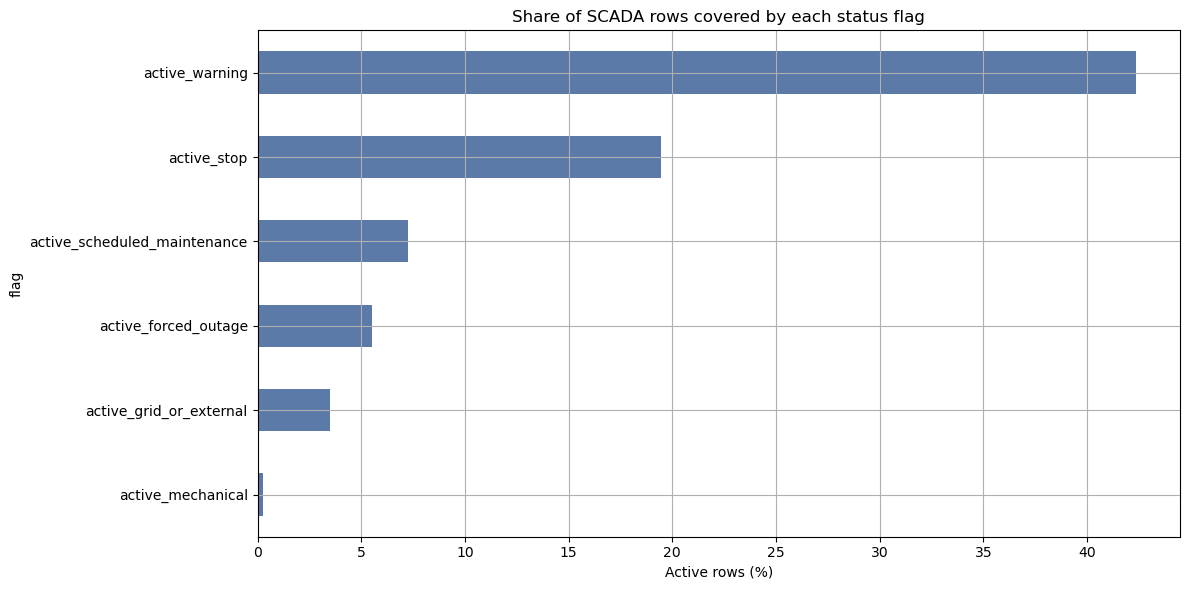

In [34]:
flag_cols = [col for col in combined.columns if col.startswith("active_")]
prevalence = pd.DataFrame({
    "flag": flag_cols,
    "active_rows": [int(combined[col].sum()) for col in flag_cols],
    "active_pct": [combined[col].mean() * 100 for col in flag_cols],
})
display(prevalence)

ax = prevalence.sort_values("active_pct").plot.barh(x="flag", y="active_pct", legend=False, color="#5b7aa8")
ax.set_title("Share of SCADA rows covered by each status flag")
ax.set_xlabel("Active rows (%)")
plt.tight_layout()

Status,Informational,Stop,Warning
turbine,,,
T01,2724.440833,606.006389,2186.963056
T02,2505.847500,678.693889,2618.449444
T04,2527.280556,634.775278,1933.882222
T05,2417.426667,341.432500,2125.347500
T06,2650.878889,1816.017222,5332.874444
T07,2612.805278,539.955556,2773.458333
T08,2711.916667,646.951111,1167.528056
T09,4833.536111,1495.070556,1145.803889
T10,3419.895833,1640.256111,2270.448889


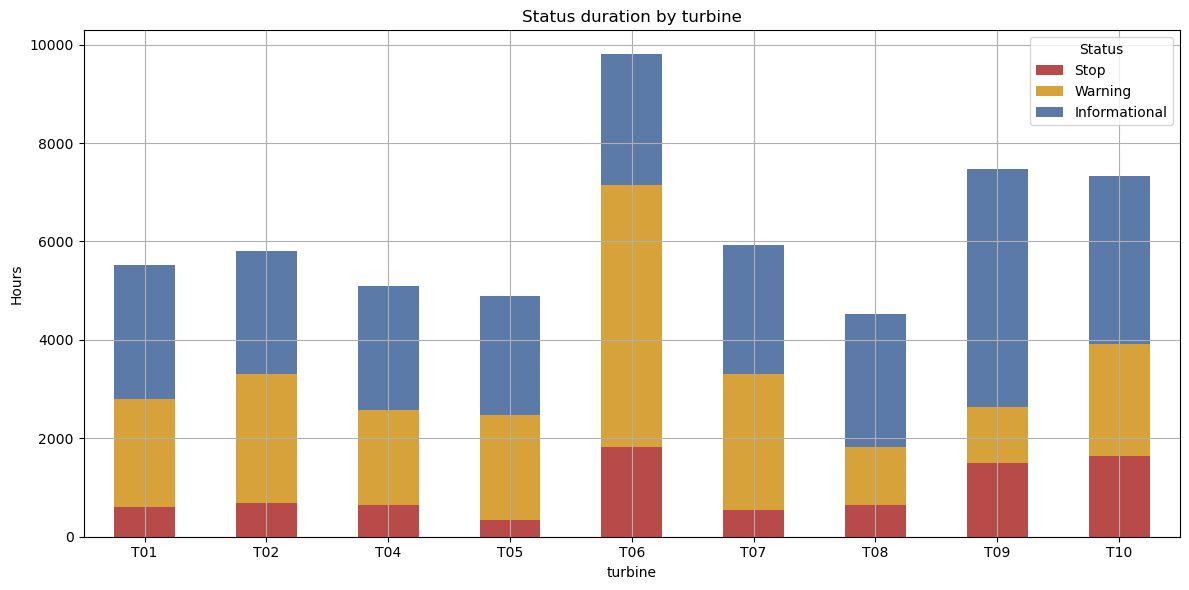

In [35]:
duration_by_turbine = (
    statuses.groupby(["turbine", "Status"], dropna=False)["duration_hours"]
    .sum()
    .reset_index()
)
duration_pivot = duration_by_turbine.pivot_table(index="turbine", columns="Status", values="duration_hours", fill_value=0)
display(duration_pivot)

duration_pivot[[c for c in ["Stop", "Warning", "Informational"] if c in duration_pivot.columns]].plot(
    kind="bar", stacked=True, color=["#b84a4a", "#d8a23a", "#5b7aa8"]
)
plt.title("Status duration by turbine")
plt.ylabel("Hours")
plt.xticks(rotation=0)
plt.tight_layout()

,Code,Message,Status,duration_hours
0,0,System OK,Informational,20798.647778
117,9000,P output externally reduced,Warning,12439.043333
2,20,Manual stop - on site,Stop,3080.943611
111,7324,Check time synchronization,Warning,2254.290000
75,3547,Overfrequency,Informational,1821.243889
14,245,Parameterized P red.,Informational,1705.870000
105,6622,Vane 2 defect,Warning,1631.848333
16,402,Semi-automatic operation,Informational,1374.203611
17,414,Test brake program 180,Stop,1317.129722
115,8400,Comm. failure FPM,Warning,1208.129167


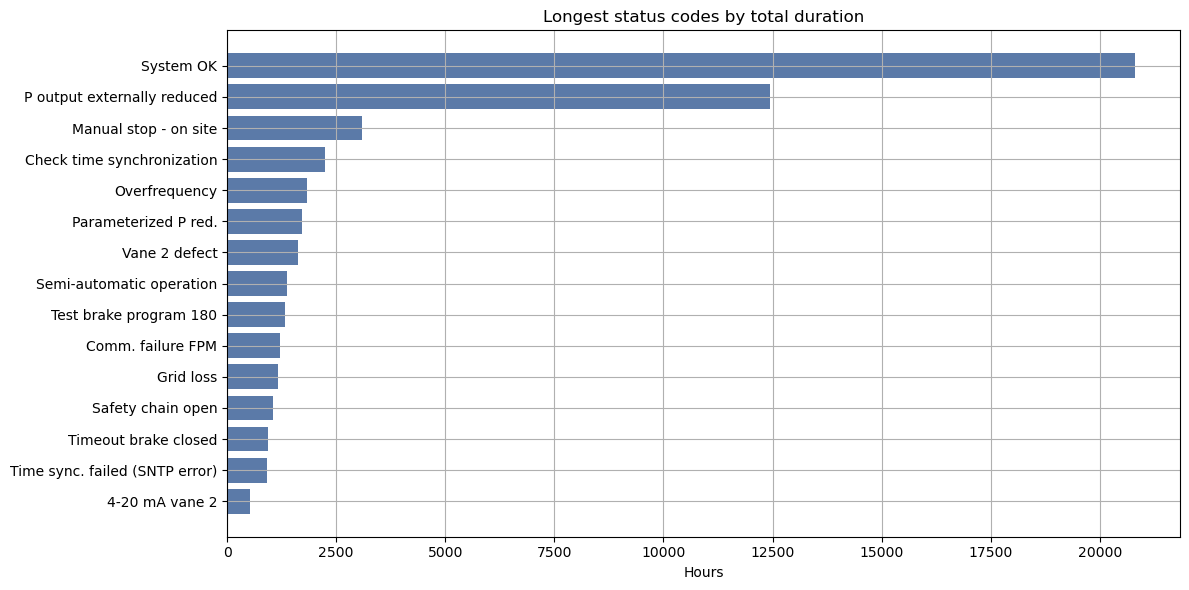

In [36]:
top_status_codes = (
    statuses.groupby(["Code", "Message", "Status"], dropna=False)["duration_hours"]
    .sum()
    .reset_index()
    .sort_values("duration_hours", ascending=False)
    .head(15)
)
display(top_status_codes)

plot_data = top_status_codes.sort_values("duration_hours")
plt.barh(plot_data["Message"].astype(str), plot_data["duration_hours"], color="#5b7aa8")
plt.title("Longest status codes by total duration")
plt.xlabel("Hours")
plt.tight_layout()

## 5. Correlation Analysis

For binary event flags, Pearson correlation is equivalent to point-biserial correlation. It is a quick way to see which SCADA signals move most strongly when an event is active.

In [37]:
def top_correlations(df: pd.DataFrame, target: str, columns: list[str], top_n: int = 15) -> pd.DataFrame:
    rows = []
    y = df[target].astype(float)
    for col in columns:
        if col not in df.columns or df[col].notna().mean() < 0.35 or df[col].nunique(dropna=True) <= 2:
            continue
        pair = pd.concat([df[col], y], axis=1).dropna()
        if len(pair) < 500 or pair[target].nunique() < 2:
            continue
        corr_value = pair[col].corr(pair[target])
        rows.append({
            "target": target,
            "signal": col,
            "correlation": corr_value,
            "abs_correlation": abs(corr_value),
            "mean_inactive": pair.loc[pair[target] == 0, col].mean(),
            "mean_active": pair.loc[pair[target] == 1, col].mean(),
            "rows": len(pair),
        })
    return pd.DataFrame(rows).sort_values("abs_correlation", ascending=False).head(top_n)


all_corr = pd.concat(
    [top_correlations(combined, flag, SCADA_COLUMNS, top_n=15) for flag in flag_cols],
    ignore_index=True,
)
display(all_corr.head(20))
all_corr.to_csv(OUTPUT_DIR / "notebook_correlations.csv", index=False)

,target,signal,correlation,abs_correlation,mean_inactive,mean_active,rows
0,active_stop,Time-based System Avail.,-0.992595,0.992595,0.997639,0.007486,255783
1,active_stop,Available Capacity for Production (kW),-0.992595,0.992595,2045.159654,15.347278,255783
2,active_stop,Production-based System Avail.,-0.838427,0.838427,0.997431,0.261056,229447
3,active_stop,Lost Production to Downtime (kWh),0.598599,0.598599,0.476199,80.768876,255783
4,active_stop,Lost Production Total (kWh),0.583125,0.583125,1.434136,80.768876,255783
5,active_stop,Gear oil pump pressure (bar),-0.534289,0.534289,5.370986,1.897130,229447
6,active_stop,Gear oil inlet pressure (bar),-0.511499,0.511499,1.789066,0.494226,229447
7,active_stop,Rotor speed (RPM),-0.505397,0.505397,11.522913,1.489194,229442
8,active_stop,Generator RPM (RPM),-0.408291,0.408291,1212.723392,143.549868,229447
9,active_stop,Reactive power (kvar),0.393717,0.393717,-192.902190,-23.593132,229447


,signal,correlation,mean_inactive,mean_active
0,Time-based System Avail.,-0.992595,0.997639,0.007486
1,Available Capacity for Production (kW),-0.992595,2045.159654,15.347278
2,Production-based System Avail.,-0.838427,0.997431,0.261056
3,Lost Production to Downtime (kWh),0.598599,0.476199,80.768876
4,Lost Production Total (kWh),0.583125,1.434136,80.768876
5,Gear oil pump pressure (bar),-0.534289,5.370986,1.897130
6,Gear oil inlet pressure (bar),-0.511499,1.789066,0.494226
7,Rotor speed (RPM),-0.505397,11.522913,1.489194
8,Generator RPM (RPM),-0.408291,1212.723392,143.549868
9,Reactive power (kvar),0.393717,-192.902190,-23.593132


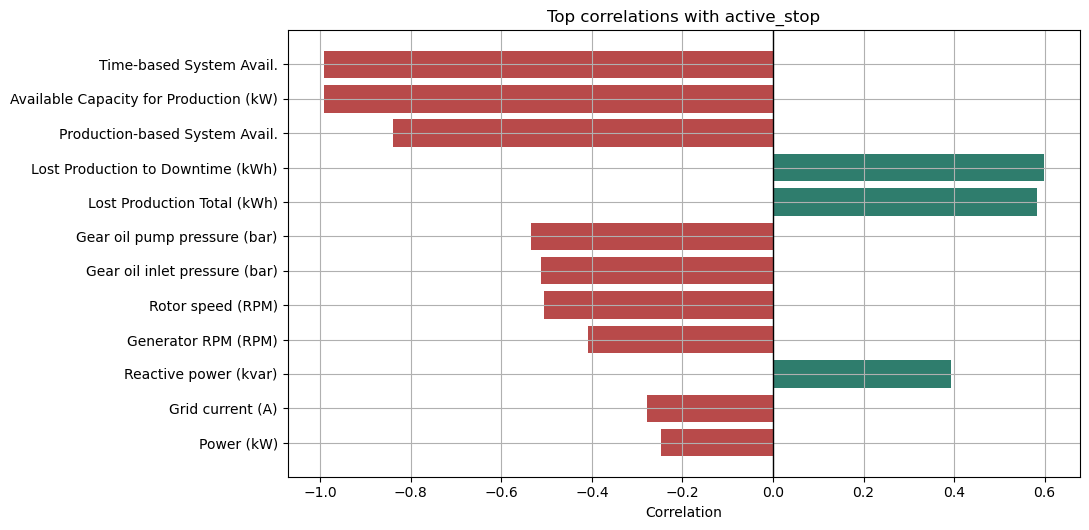

In [38]:
def plot_corr(target: str, exclude_leakage: bool = False, n: int = 12):
    data = all_corr[all_corr["target"] == target].copy()
    if exclude_leakage:
        data = data[~data["signal"].isin(LEAKAGE_COLUMNS)]
    data = data.sort_values("abs_correlation", ascending=False).head(n)
    colors = np.where(data["correlation"] >= 0, "#2f7d6d", "#b84a4a")
    plt.figure(figsize=(11, max(4, n * 0.45)))
    plt.barh(data["signal"], data["correlation"], color=colors)
    plt.axvline(0, color="black", linewidth=1)
    plt.gca().invert_yaxis()
    plt.title(f"Top correlations with {target}" + (" excluding leakage fields" if exclude_leakage else ""))
    plt.xlabel("Correlation")
    plt.tight_layout()
    return data[["signal", "correlation", "mean_inactive", "mean_active"]]

plot_corr("active_stop")

,signal,correlation,mean_inactive,mean_active
33,Gear oil pump pressure (bar),-0.421613,5.209180,1.468599
34,Gear oil inlet pressure (bar),-0.405478,1.729088,0.328446
35,Rotor speed (RPM),-0.404916,11.064198,0.094794
36,Generator RPM (RPM),-0.325381,1163.520245,0.842265
39,Reactive power (kvar),0.313693,-185.108375,-1.035344
40,Grid current (A),-0.220657,488.270459,7.621478
41,Power (kW),-0.194003,523.573686,1.340219
42,Drive train acceleration (mm/ss),-0.100040,0.655651,0.426784
43,"Wind speed, Standard deviation (m/s)",0.056698,0.873370,1.013239


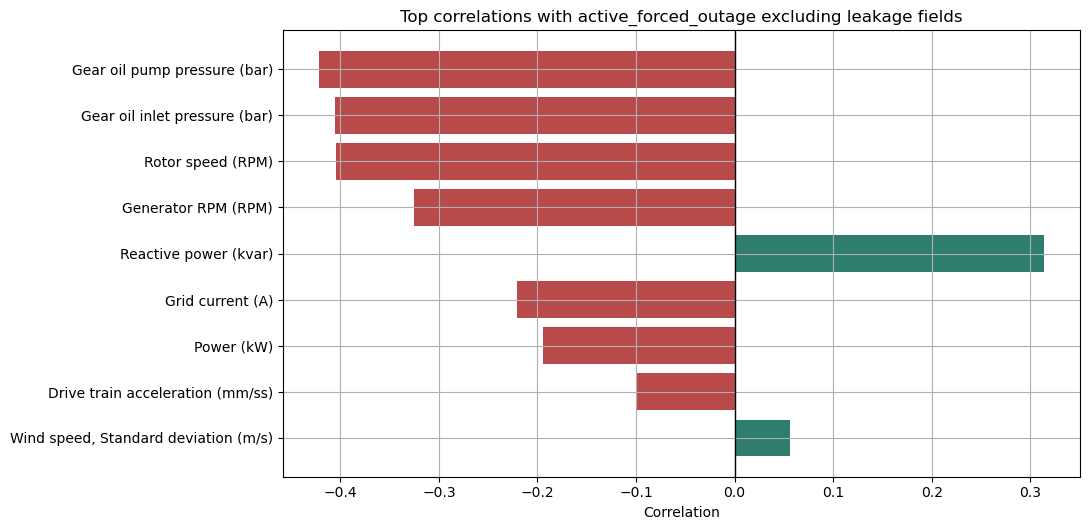

In [39]:
plot_corr("active_forced_outage", exclude_leakage=True)

,signal,correlation,mean_inactive,mean_active
62,Grid frequency (Hz),-0.293564,49.984332,45.375843
63,Grid voltage (V),-0.286179,694.770717,631.804021
67,Gear oil pump pressure (bar),-0.150315,5.062216,3.204503
68,Gear oil inlet pressure (bar),-0.138238,1.673260,1.008078
69,Rotor speed (RPM),-0.131734,10.620705,5.649450
70,Generator RPM (RPM),-0.106888,1116.648840,584.603346
71,Reactive power (kvar),0.106470,-177.761166,-90.732177
72,Grid current (A),-0.079779,469.474564,227.400268
73,Power (kW),-0.072207,503.354828,232.593088
74,Drive train acceleration (mm/ss),-0.043352,0.647302,0.509146


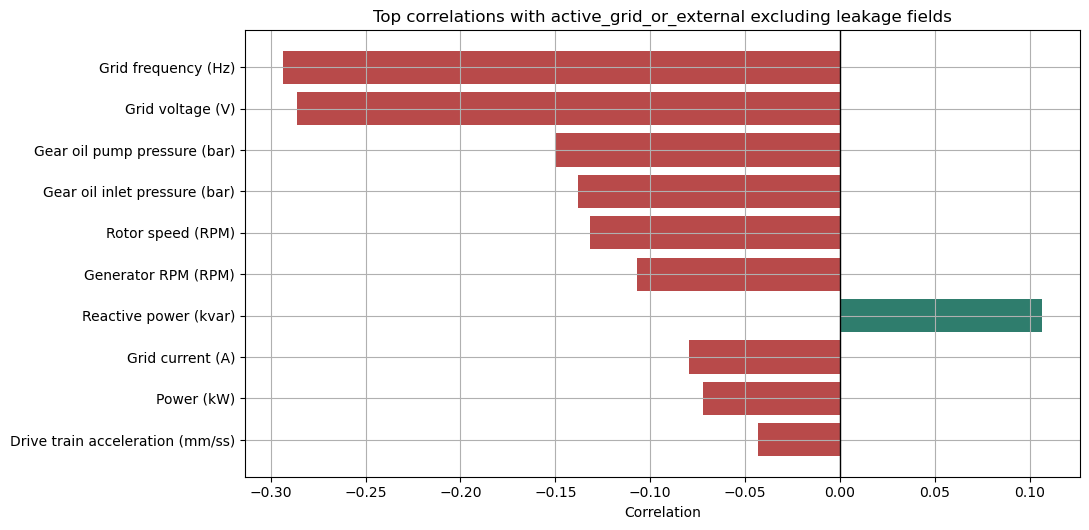

In [40]:
plot_corr("active_grid_or_external", exclude_leakage=True)

## 6. Signal Distributions During Events

,count,mean,std,min,25%,50%,75%,max
active_forced_outage,,,,,,,,
active,2618.0,1.802345,40.678975,-11.20,-1.830000,-1.025000,-0.440000,969.450012
inactive,47382.0,524.564636,605.239121,-15.37,33.104999,277.980011,811.337479,2061.679932


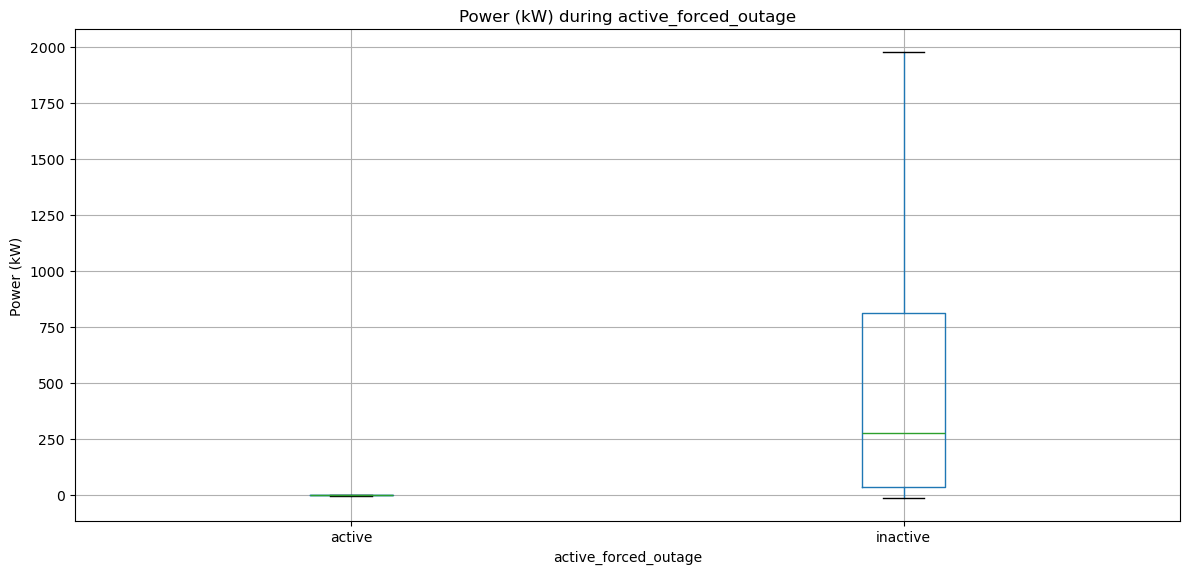

In [41]:
def compare_signal(signal: str, flag: str, sample_size: int = 50000):
    data = combined[[signal, flag]].dropna().copy()
    data[flag] = np.where(data[flag], "active", "inactive")
    if len(data) > sample_size:
        data = data.sample(sample_size, random_state=42)
    display(data.groupby(flag)[signal].describe())
    data.boxplot(column=signal, by=flag, showfliers=False)
    plt.title(f"{signal} during {flag}")
    plt.suptitle("")
    plt.xlabel(flag)
    plt.ylabel(signal)
    plt.tight_layout()

compare_signal("Power (kW)", "active_forced_outage")

,count,mean,std,min,25%,50%,75%,max
active_grid_or_external,,,,,,,,
active,1289.0,44.864717,15.162396,0.0,49.950001,49.980000,50.02,50.139999
inactive,48711.0,49.986016,0.430698,0.0,49.959999,49.990002,50.02,50.150002


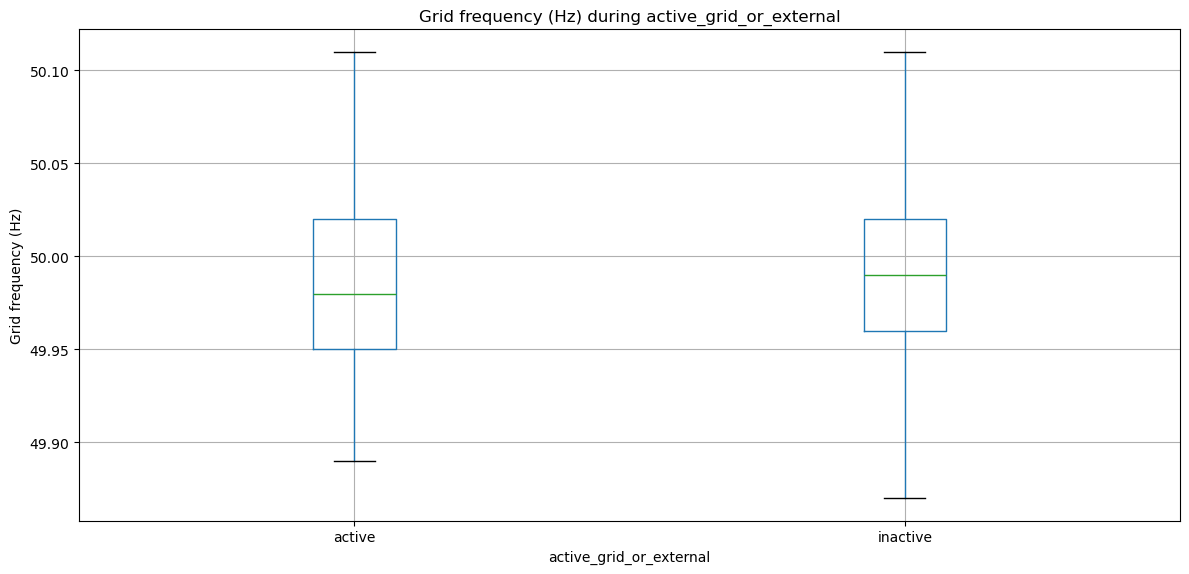

In [42]:
compare_signal("Grid frequency (Hz)", "active_grid_or_external")

,count,mean,std,min,25%,50%,75%,max
active_stop,,,,,,,,
active,5171.0,1.861967,2.091090,0.00,0.30,0.67,3.41,11.75
inactive,44829.0,5.369426,1.618325,0.04,4.74,5.31,6.22,12.64


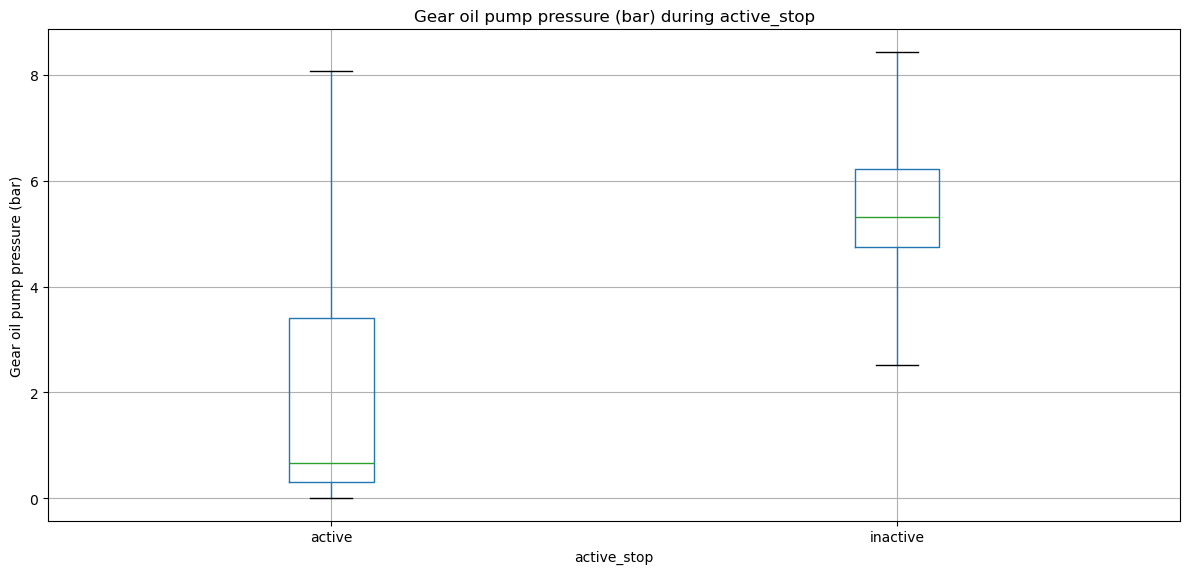

In [43]:
compare_signal("Gear oil pump pressure (bar)", "active_stop")

## 7. Time-Series Inspection

The shaded regions below mark active forced-outage rows. Change the turbine and window to inspect other periods.

,timestamp,Power (kW),Wind speed (m/s),active_stop,active_forced_outage
126680,2016-08-01 00:00:00,296.369995,6.06,True,False
126681,2016-08-01 00:10:00,381.130005,6.39,True,False
126682,2016-08-01 00:20:00,358.700012,6.40,True,False
126683,2016-08-01 00:30:00,324.809998,6.19,True,False
126684,2016-08-01 00:40:00,327.820007,6.20,True,False
126685,2016-08-01 00:50:00,275.010010,5.92,True,False
126686,2016-08-01 01:00:00,233.279999,5.56,True,False
126687,2016-08-01 01:10:00,356.000000,6.17,True,False
126688,2016-08-01 01:20:00,338.079987,6.09,True,False
126689,2016-08-01 01:30:00,279.540009,5.72,True,False


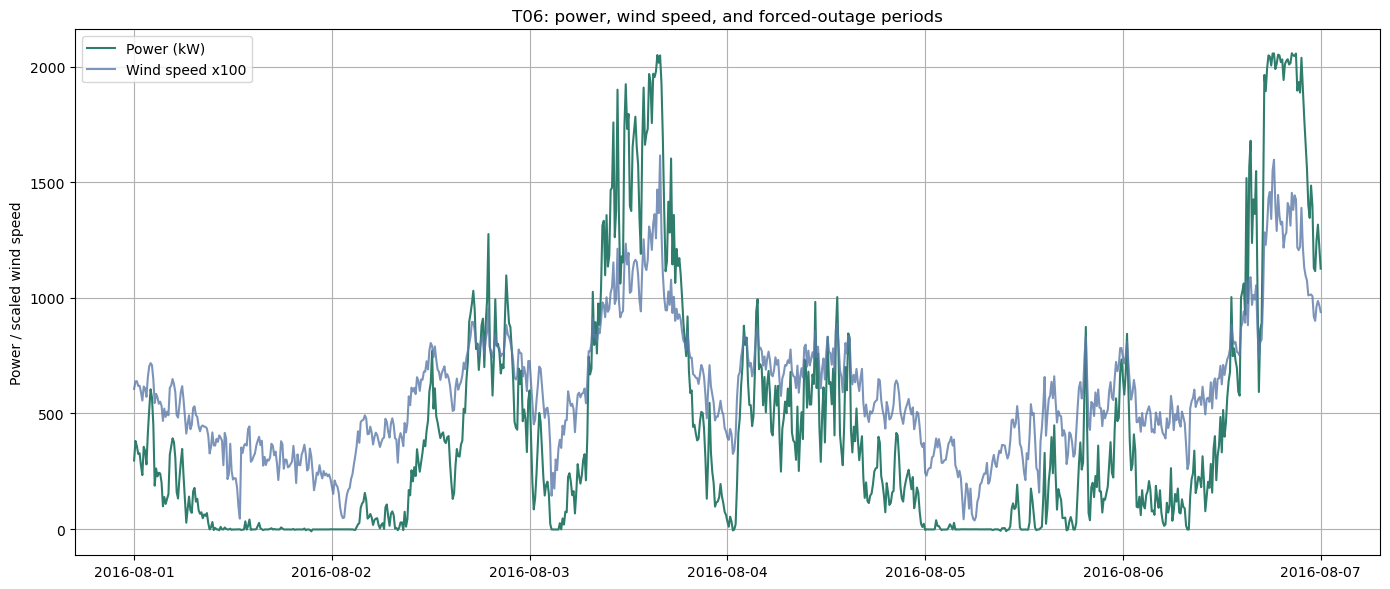

In [44]:
def plot_turbine_window(turbine="T06", start="2016-08-01", end="2016-08-07"):
    data = combined[combined["turbine"].eq(turbine)].copy()
    data = data[(data["timestamp"] >= pd.Timestamp(start)) & (data["timestamp"] <= pd.Timestamp(end))]
    if data.empty:
        print("No rows in that window.")
        return pd.DataFrame()
    plt.figure(figsize=(14, 6))
    plt.plot(data["timestamp"], data["Power (kW)"], label="Power (kW)", color="#2f7d6d")
    plt.plot(data["timestamp"], data["Wind speed (m/s)"] * 100, label="Wind speed x100", color="#5b7aa8", alpha=0.8)
    for _, row in data[data["active_forced_outage"]].iterrows():
        plt.axvspan(row["timestamp"], row["timestamp"] + pd.Timedelta(minutes=10), color="#b84a4a", alpha=0.12)
    plt.title(f"{turbine}: power, wind speed, and forced-outage periods")
    plt.ylabel("Power / scaled wind speed")
    plt.legend()
    plt.tight_layout()
    return data[["timestamp", "Power (kW)", "Wind speed (m/s)", "active_stop", "active_forced_outage"]].head(20)

plot_turbine_window("T06", "2016-08-01", "2016-08-07")

## 8. Build A Multiclass Modeling Dataset

The model target below is `next_event_type_60m`: the highest-priority status/failure type that becomes active in the next six 10-minute rows for the same turbine.

Classes are mutually exclusive. If multiple event types occur in the lookahead window, we apply this priority order:

1. `mechanical_issue`
2. `grid_or_external`
3. `forced_outage`
4. `scheduled_maintenance`
5. `stop_other`
6. `warning`
7. `no_event`

Rows where the turbine is already in a major stop/outage/maintenance/grid/mechanical state are excluded, so the model is predicting the next event type rather than describing an event already in progress.

For features, we exclude obvious leakage fields such as availability, lost production, energy export, and performance index. The remaining features are physical or near-real-time operational SCADA measurements.

In [45]:
model_data = combined.sort_values(["turbine", "timestamp"]).copy()
future_steps = 6

EVENT_PRIORITY = [
    ("mechanical_issue", "active_mechanical"),
    ("grid_or_external", "active_grid_or_external"),
    ("forced_outage", "active_forced_outage"),
    ("scheduled_maintenance", "active_scheduled_maintenance"),
    ("stop_other", "active_stop"),
    ("warning", "active_warning"),
]

future_event_masks = {}
for class_name, flag in EVENT_PRIORITY:
    shifted_flags = []
    for step in range(1, future_steps + 1):
        shifted = model_data.groupby("turbine")[flag].shift(-step).fillna(False).astype(bool)
        shifted_flags.append(shifted.to_numpy())
    future_event_masks[class_name] = np.column_stack(shifted_flags).any(axis=1)

# Assign lower-priority classes first, then overwrite with higher-priority classes.
next_event_type = np.full(len(model_data), "no_event", dtype=object)
for class_name, _ in reversed(EVENT_PRIORITY):
    next_event_type[future_event_masks[class_name]] = class_name

model_data["next_event_type_60m"] = next_event_type

current_major_event = (
    model_data["active_stop"]
    | model_data["active_forced_outage"]
    | model_data["active_scheduled_maintenance"]
    | model_data["active_grid_or_external"]
    | model_data["active_mechanical"]
)
model_data = model_data[~current_major_event].copy()

candidate_features = [
    col for col in SCADA_COLUMNS
    if col in model_data.columns and col not in LEAKAGE_COLUMNS
]
candidate_features = [
    col for col in candidate_features
    if model_data[col].notna().mean() >= 0.35 and model_data[col].nunique(dropna=True) > 2
]

class_counts = model_data["next_event_type_60m"].value_counts()
min_class_rows = 30
kept_classes = class_counts[class_counts >= min_class_rows].index.tolist()
model_data = model_data[model_data["next_event_type_60m"].isin(kept_classes)].copy()

X = model_data[candidate_features].astype("float32")
y_labels = model_data["next_event_type_60m"].astype(str)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_.tolist()
class_to_id = {name: int(label_encoder.transform([name])[0]) for name in class_names}

print("Rows:", len(X))
print("Feature count:", len(candidate_features))
print("Classes:", class_to_id)
display(y_labels.value_counts().rename_axis("class").reset_index(name="rows"))
display(pd.DataFrame({"feature": candidate_features}))

C:\Users\KIPTOON\AppData\Local\Temp\ipykernel_21804\4205674643.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shifted = model_data.groupby("turbine")[flag].shift(-step).fillna(False).astype(bool)
C:\Users\KIPTOON\AppData\Local\Temp\ipykernel_21804\4205674643.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shifted = model_data.groupby("turbine")[flag].shift(-step).fillna(False).astype(bool)
C:\Users\KIPTOON\AppData\Local\Temp\ipykernel_21804\4205674643.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecate

C:\Users\KIPTOON\AppData\Local\Temp\ipykernel_21804\4205674643.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shifted = model_data.groupby("turbine")[flag].shift(-step).fillna(False).astype(bool)
C:\Users\KIPTOON\AppData\Local\Temp\ipykernel_21804\4205674643.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  shifted = model_data.groupby("turbine")[flag].shift(-step).fillna(False).astype(bool)
C:\Users\KIPTOON\AppData\Local\Temp\ipykernel_21804\4205674643.py:17: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecate

Rows: 205898
Feature count: 14
Classes: {'forced_outage': 0, 'grid_or_external': 1, 'mechanical_issue': 2, 'no_event': 3, 'scheduled_maintenance': 4, 'stop_other': 5, 'warning': 6}


,class,rows
0,no_event,120595
1,warning,79739
2,grid_or_external,3185
3,stop_other,996
4,scheduled_maintenance,785
5,forced_outage,438
6,mechanical_issue,160


,feature
0,Wind speed (m/s)
1,"Wind speed, Standard deviation (m/s)"
2,Density adjusted wind speed (m/s)
3,Power (kW)
4,Potential power default PC (kW)
5,Rotor speed (RPM)
6,Generator RPM (RPM)
7,Grid voltage (V)
8,Grid current (A)
9,Reactive power (kvar)


## 9. Train And Evaluate The Multiclass Model

A balanced multinomial logistic regression is still a good take-home baseline: it is explainable, handles class imbalance, exports cleanly to ONNX, and gives a probability distribution across event types.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42,
            multi_class="multinomial",
        ),
    ),
])

pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)
proba = pipeline.predict_proba(X_test)

print(classification_report(y_test, pred, target_names=class_names, digits=3))
print("Balanced accuracy:", balanced_accuracy_score(y_test, pred))
print("Top-2 accuracy:", top_k_accuracy_score(y_test, proba, k=2, labels=np.arange(len(class_names))))

C:\Users\KIPTOON\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


                       precision    recall  f1-score   support

        forced_outage      0.015     0.227     0.028        88
     grid_or_external      0.043     0.507     0.079       637
     mechanical_issue      0.003     0.344     0.005        32
             no_event      0.853     0.351     0.497     24119
scheduled_maintenance      0.007     0.248     0.013       157
           stop_other      0.010     0.216     0.019       199
              warning      0.698     0.361     0.476     15948

             accuracy                          0.356     41180
            macro avg      0.233     0.322     0.160     41180
         weighted avg      0.771     0.356     0.477     41180

Balanced accuracy: 0.3220398808457728
Top-2 accuracy: 0.5545167557066537


,count,mean,std,min,25%,50%,75%,max
no_event,41180.0,0.180978,0.101021,5.645335e-12,0.107426,0.155853,0.221893,0.682174
warning,41180.0,0.169273,0.081091,1.579570e-49,0.108939,0.155756,0.218221,0.617224
stop_other,41180.0,0.152601,0.058877,3.288099e-51,0.114164,0.151852,0.191480,0.433890
scheduled_maintenance,41180.0,0.143514,0.084225,1.424082e-07,0.080646,0.130737,0.191346,0.676550
grid_or_external,41180.0,0.124548,0.113167,1.188523e-04,0.039725,0.097258,0.172167,0.999429
forced_outage,41180.0,0.117687,0.060722,6.817021e-05,0.080995,0.108226,0.141191,0.874993
mechanical_issue,41180.0,0.111400,0.092711,7.512189e-05,0.048518,0.080789,0.146164,0.864219


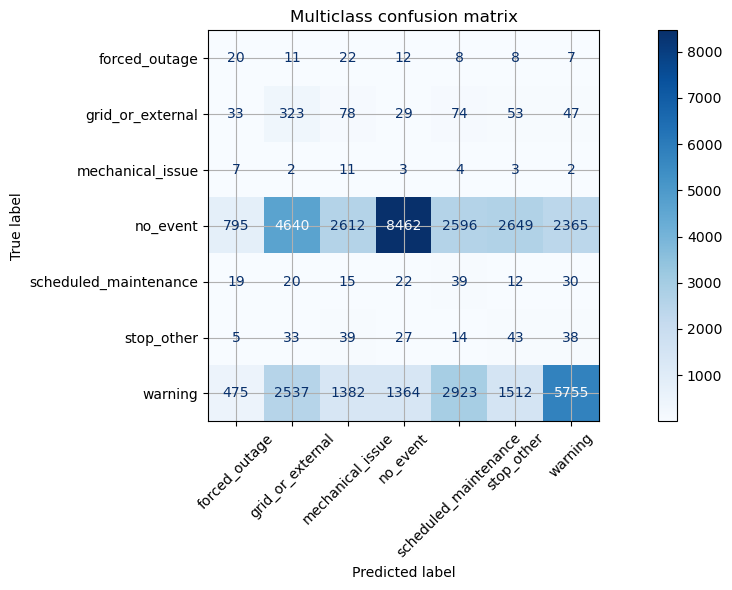

In [47]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=class_names,
    cmap="Blues",
    xticks_rotation=45,
)
plt.title("Multiclass confusion matrix")
plt.tight_layout()

proba_frame = pd.DataFrame(proba, columns=class_names)
display(proba_frame.describe().T.sort_values("mean", ascending=False))

,class,feature,coefficient,abs_coefficient
86,warning,Density adjusted wind speed (m/s),-25.930795,25.930795
84,warning,Wind speed (m/s),25.759959,25.759959
42,no_event,Wind speed (m/s),-21.096621,21.096621
44,no_event,Density adjusted wind speed (m/s),20.483512,20.483512
58,scheduled_maintenance,Density adjusted wind speed (m/s),-16.153116,16.153116
56,scheduled_maintenance,Wind speed (m/s),15.839900,15.839900
30,mechanical_issue,Density adjusted wind speed (m/s),9.572790,9.572790
17,grid_or_external,Power (kW),-9.365253,9.365253
28,mechanical_issue,Wind speed (m/s),-9.190440,9.190440
22,grid_or_external,Grid current (A),8.562164,8.562164


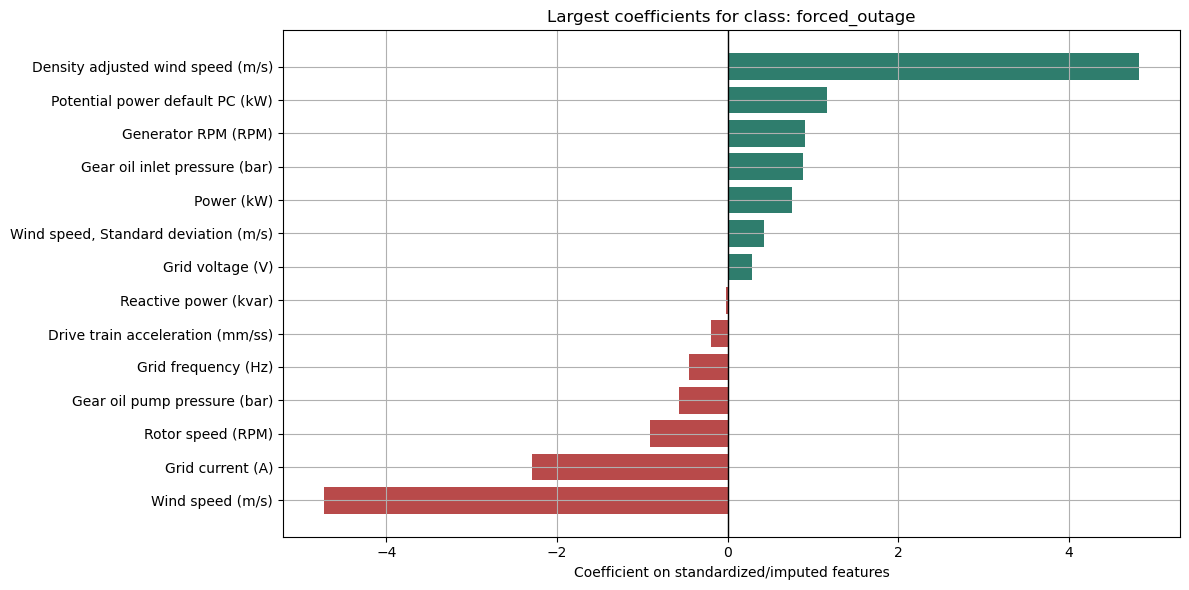

In [48]:
coef = pipeline.named_steps["classifier"].coef_
coef_tables = []
for class_index, class_name in enumerate(class_names):
    table = pd.DataFrame({
        "class": class_name,
        "feature": candidate_features,
        "coefficient": coef[class_index],
    })
    table["abs_coefficient"] = table["coefficient"].abs()
    coef_tables.append(table)

coef_table = pd.concat(coef_tables, ignore_index=True)
display(coef_table.sort_values("abs_coefficient", ascending=False).head(30))

class_to_plot = "forced_outage" if "forced_outage" in class_names else class_names[0]
plot_data = (
    coef_table[coef_table["class"] == class_to_plot]
    .sort_values("abs_coefficient", ascending=False)
    .head(15)
    .sort_values("coefficient")
)
colors = np.where(plot_data["coefficient"] >= 0, "#2f7d6d", "#b84a4a")
plt.barh(plot_data["feature"], plot_data["coefficient"], color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Largest coefficients for class: {class_to_plot}")
plt.xlabel("Coefficient on standardized/imputed features")
plt.tight_layout()

## 10. Export To ONNX

The exported bundle contains:
- `model.onnx`: the ONNX model
- `metadata.json`: input name, output names, feature order, metrics, and target definition
- `model.joblib`: the sklearn pipeline for local debugging only

In [49]:
version = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ")
bundle_dir = MODEL_REPOSITORY / version
bundle_dir.mkdir(parents=True, exist_ok=True)

input_name = "float_input"
label_output = "label"
probability_output = "probabilities"

onnx_model = convert_sklearn(
    pipeline,
    initial_types=[(input_name, FloatTensorType([None, len(candidate_features)]))],
    target_opset=17,
    options={id(pipeline.named_steps["classifier"]): {"zipmap": False}},
)

onnx_path = bundle_dir / "model.onnx"
metadata_path = bundle_dir / "metadata.json"
joblib_path = bundle_dir / "model.joblib"

onnx_path.write_bytes(onnx_model.SerializeToString())
joblib.dump(pipeline, joblib_path)

metadata = {
    "run_id": version,
    "model_name": "notebook-penmanshiel-event-type-onnx",
    "version": version,
    "task": "multiclass_classification",
    "target": "next_event_type_60m",
    "target_definition": "Highest-priority event/status type active within the next six 10-minute SCADA rows for the same turbine; rows already in major events excluded.",
    "input_name": input_name,
    "label_output": label_output,
    "probability_output": probability_output,
    "class_names": class_names,
    "class_to_id": class_to_id,
    "feature_names": candidate_features,
    "metrics": {
        "balanced_accuracy": float(balanced_accuracy_score(y_test, pred)),
        "top_2_accuracy": float(top_k_accuracy_score(y_test, proba, k=2, labels=np.arange(len(class_names)))),
        "train_rows": int(len(X_train)),
        "test_rows": int(len(X_test)),
        "class_count": int(len(class_names)),
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Exported bundle:", bundle_dir)
print("ONNX size MB:", onnx_path.stat().st_size / 1_000_000)
display(metadata)

Exported bundle: C:\Users\KIPTOON\Documents\Playground\wind-onnx-mlops-takehome\model_repository\notebook-penmanshiel-event-type-onnx\20260521T104608Z
ONNX size MB: 0.001405


{'run_id': '20260521T104608Z',
 'model_name': 'notebook-penmanshiel-event-type-onnx',
 'version': '20260521T104608Z',
 'task': 'multiclass_classification',
 'target': 'next_event_type_60m',
 'target_definition': 'Highest-priority event/status type active within the next six 10-minute SCADA rows for the same turbine; rows already in major events excluded.',
 'input_name': 'float_input',
 'label_output': 'label',
 'probability_output': 'probabilities',
 'class_names': ['forced_outage',
  'grid_or_external',
  'mechanical_issue',
  'no_event',
  'scheduled_maintenance',
  'stop_other',
  'warning'],
 'class_to_id': {'forced_outage': 0,
  'grid_or_external': 1,
  'mechanical_issue': 2,
  'no_event': 3,
  'scheduled_maintenance': 4,
  'stop_other': 5,
  'warning': 6},
 'feature_names': ['Wind speed (m/s)',
  'Wind speed, Standard deviation (m/s)',
  'Density adjusted wind speed (m/s)',
  'Power (kW)',
  'Potential power default PC (kW)',
  'Rotor speed (RPM)',
  'Generator RPM (RPM)',
  'Gr

## 11. ONNX Runtime Smoke Test

This verifies that the ONNX artifact can be loaded independently of sklearn and returns predictions for a representative input row.

In [50]:
session = ort.InferenceSession(str(onnx_path), providers=["CPUExecutionProvider"])
sample = X_test.iloc[:5].to_numpy(dtype=np.float32)
outputs = session.run(None, {input_name: sample})

onnx_labels = outputs[0]
onnx_probabilities = outputs[1]
probability_frame = pd.DataFrame(onnx_probabilities, columns=class_names)
probability_frame.insert(0, "predicted_class_id", onnx_labels)
probability_frame.insert(1, "predicted_class", [class_names[int(label)] for label in onnx_labels])

print("ONNX inputs:", [(i.name, i.shape, i.type) for i in session.get_inputs()])
print("ONNX outputs:", [(o.name, o.shape, o.type) for o in session.get_outputs()])
display(probability_frame)

ONNX inputs: [('float_input', [None, 14], 'tensor(float)')]
ONNX outputs: [('label', [None], 'tensor(int64)'), ('probabilities', [None, 7], 'tensor(float)')]


,predicted_class_id,predicted_class,forced_outage,grid_or_external,mechanical_issue,no_event,scheduled_maintenance,stop_other,warning
0,3,no_event,0.216666,0.023626,0.088236,0.239523,0.192973,0.078848,0.160127
1,5,stop_other,0.123375,0.126938,0.076118,0.159436,0.159200,0.183595,0.171337
2,2,mechanical_issue,0.147568,0.035518,0.422972,0.081003,0.024361,0.183670,0.104907
3,4,scheduled_maintenance,0.057102,0.023828,0.003257,0.052025,0.417874,0.084112,0.361802
4,6,warning,0.138055,0.122821,0.109595,0.073182,0.132527,0.107255,0.316566


## 12. What To Say In The Interview

- The exploratory correlations show that stops and forced outages are strongly reflected in rotor/generator speed, power, pressure, current, and grid signals.
- Availability and lost-production fields are excellent for diagnosis but poor predictive features because they can leak the label.
- The model target is forward-looking and multiclass: it predicts the next event/status type in the coming hour.
- The class labels are `no_event`, `warning`, `stop_other`, `scheduled_maintenance`, `forced_outage`, `grid_or_external`, and `mechanical_issue`, depending on which classes have enough rows in the selected data.
- The ONNX export includes `class_names` metadata so the C# API can turn numeric class ids into human-readable event types.
- This is still a baseline model, but it directly addresses the prompt option of classifying a failure type from SCADA signals.